In [1]:
import pandas as pd
import numpy as np

In [ ]:
# load daatset
csv(r"D:\PRIYANKA(AIPA)2025\Applies_AI_Module10\student_performance_dataset.csv")

In [3]:
# display first 5 rows of the dataset
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [4]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [5]:
# dataset shape
df.shape

(708, 10)

In [6]:
# missing values in the dataset
df.isnull().sum()

Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64

# Data Preprocessing

In [7]:
# convert Pass_Fail column to numerical values
df["Pass_Fail"] = df["Pass_Fail"].map({
    "Pass":1,
    "Fail":0
})

In [8]:
# convert categorical variables to numerical using one-hot encoding
df = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Parental_Education_Level",
        "Internet_Access_at_Home",
        "Extracurricular_Activities"
    ],
    drop_first=True
)

In [9]:
# drop Student_ID column as it is not useful for prediction
df.drop("Student_ID", axis=1, inplace=True)

In [10]:
# separate features and target variable
X = df.drop("Pass_Fail", axis=1)

y = df["Pass_Fail"]

In [11]:
# split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
# train a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# make predictions on the test set
y_pred = model.predict(X_test)

In [14]:
# evaluate the model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [15]:
# confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[71  0]
 [ 0 71]]


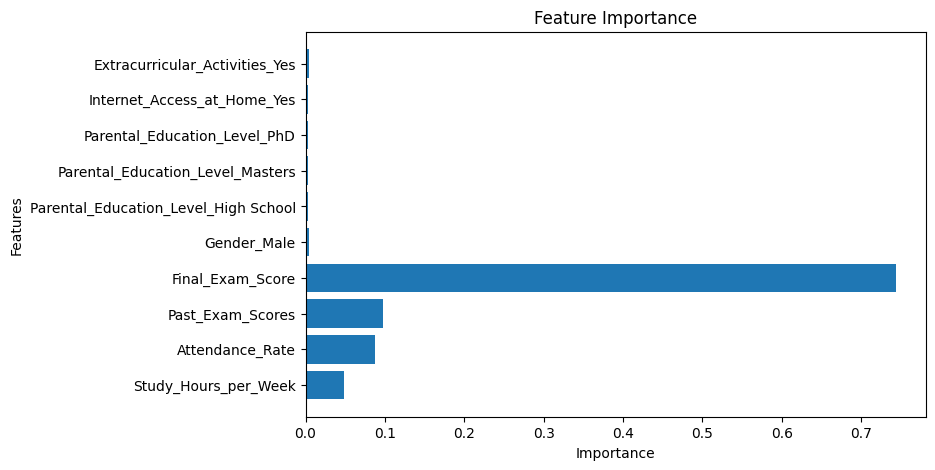

In [ ]:
# feature importance
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.show()

In [17]:
# save the model using joblib
import joblib

joblib.dump(model, "student_model.pkl")

print("Model Saved")

Model Saved
